
--- Analisis Metrik: UNDEXPOSURE ---
Technique: Original     | Entropy: 6.7581 | Contrast: 42.8876


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27952\3581130551.py:73: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[i*2+1].hist(processed.ravel(), 256, [0,256], color='black')


Technique: Negatif      | Entropy: 6.7581 | Contrast: 42.8876
Technique: Log Trans    | Entropy: 6.0997 | Contrast: 54.2981
Technique: Gamma 0.5    | Entropy: 5.6783 | Contrast: 25.2683
Technique: Gamma 2.5    | Entropy: 6.3918 | Contrast: 47.5178
Technique: Stretching   | Entropy: 6.6944 | Contrast: 82.8550
Technique: Global HE    | Entropy: 6.7048 | Contrast: 75.9085
Technique: CLAHE        | Entropy: 7.3324 | Contrast: 50.1071


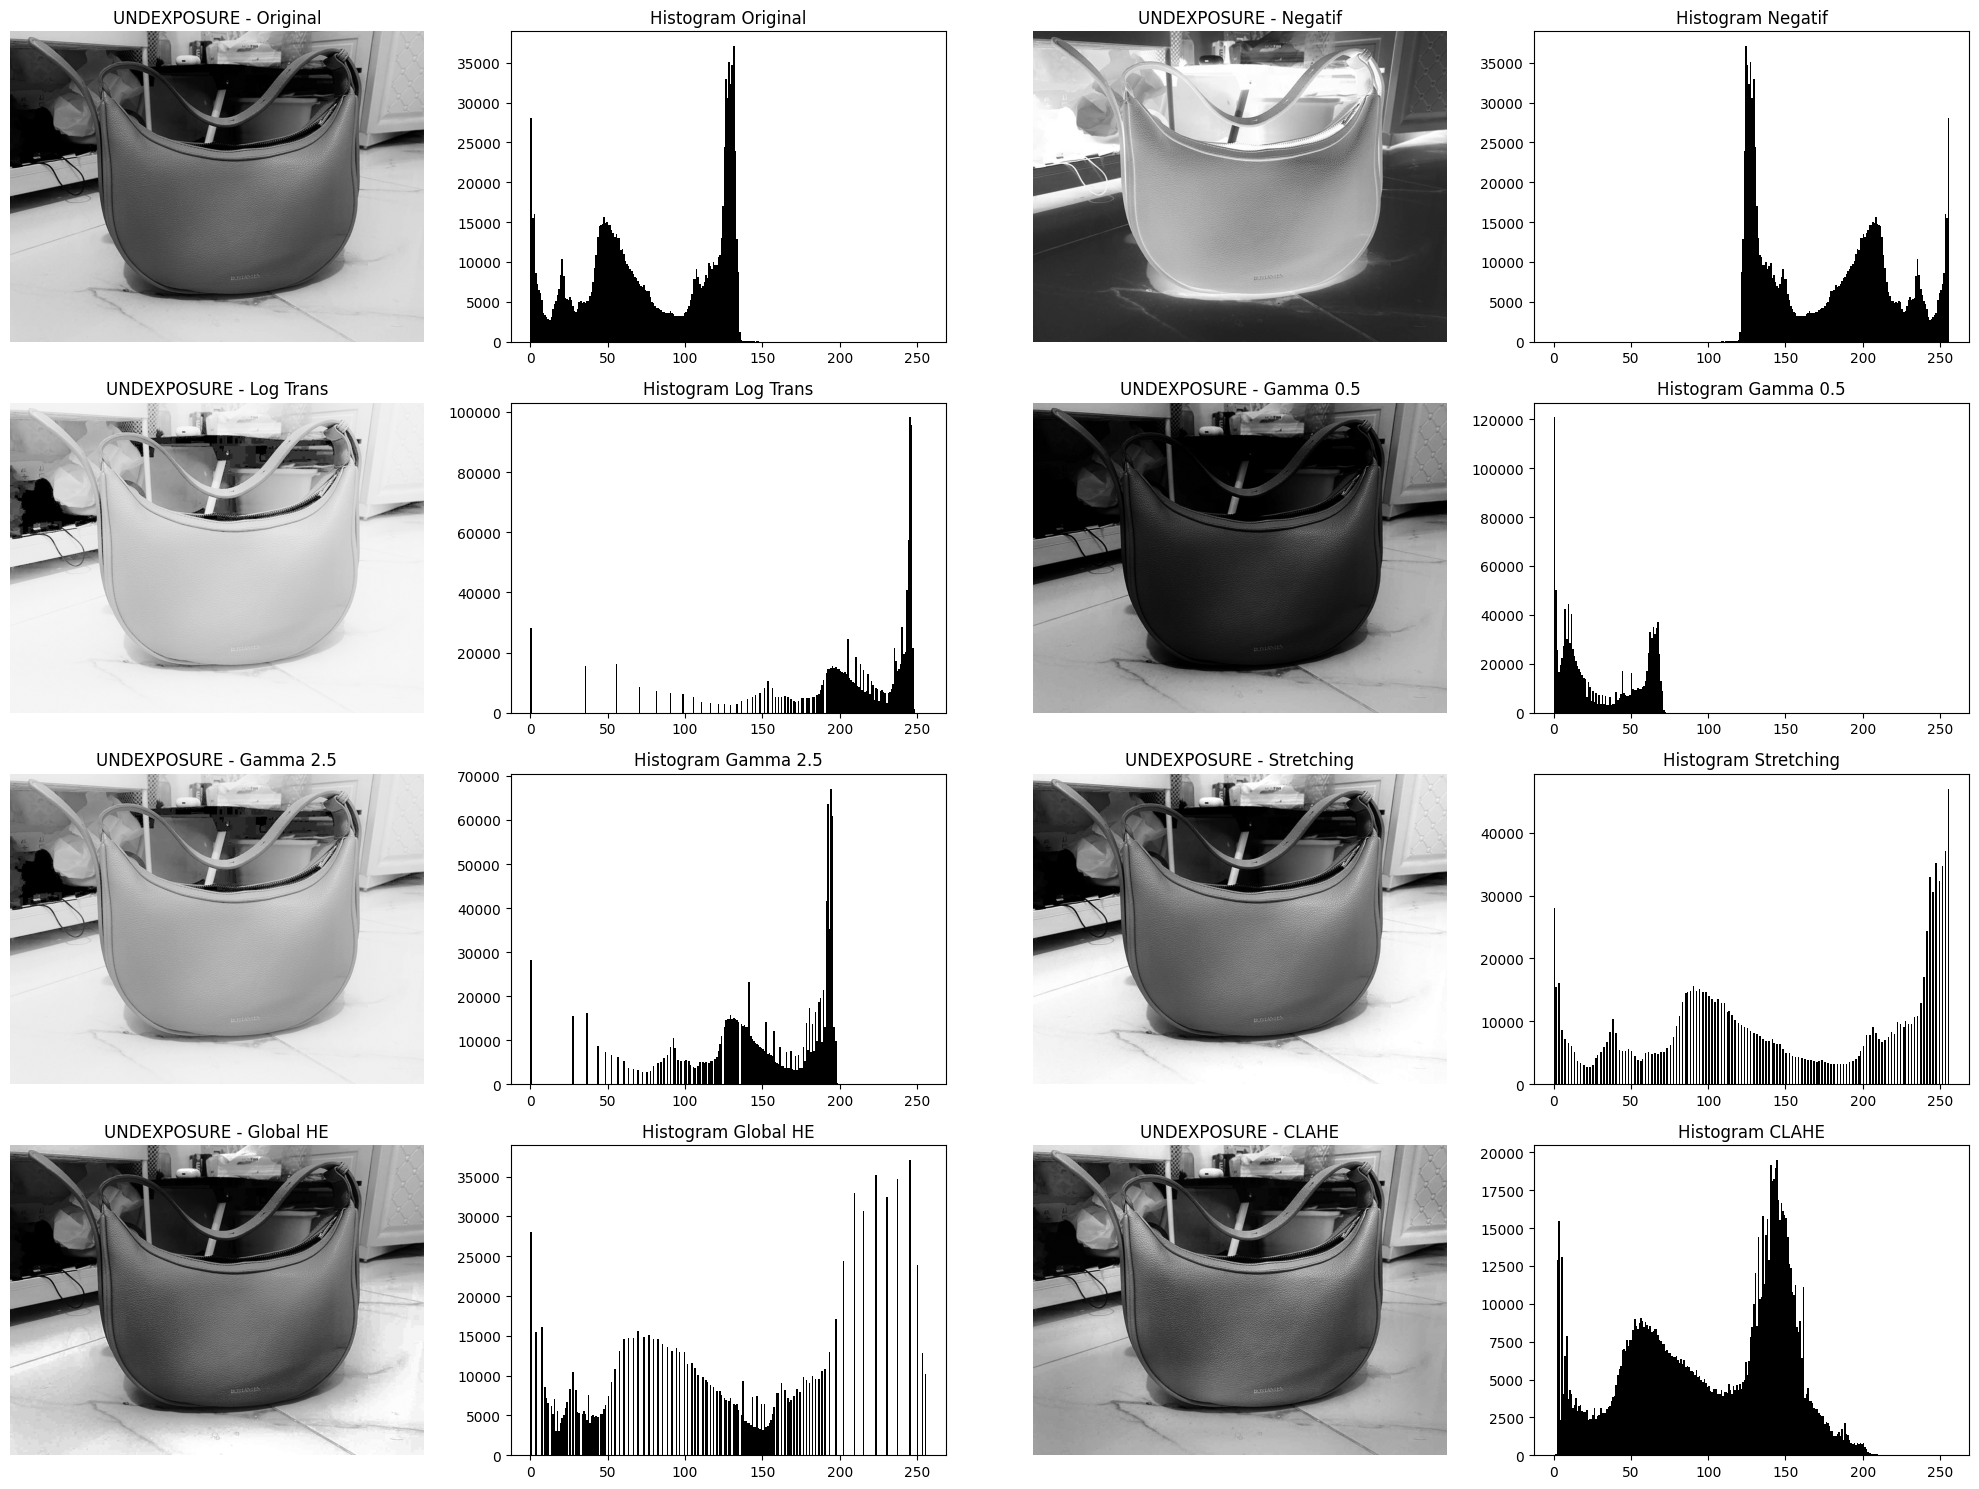

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27952\3581130551.py:21: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_27952\3581130551.py:21: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))



--- Analisis Metrik: OVEREXPOSURE ---
Technique: Original     | Entropy: 5.4573 | Contrast: 61.8001
Technique: Negatif      | Entropy: 5.4573 | Contrast: 61.8001
Technique: Log Trans    | Entropy: 0.0000 | Contrast: 0.0000
Technique: Gamma 0.5    | Entropy: 5.3074 | Contrast: 80.2412
Technique: Gamma 2.5    | Entropy: 4.8830 | Contrast: 38.5972
Technique: Stretching   | Entropy: 5.3676 | Contrast: 66.4135
Technique: Global HE    | Entropy: 5.1306 | Contrast: 94.1916
Technique: CLAHE        | Entropy: 5.6019 | Contrast: 69.2588


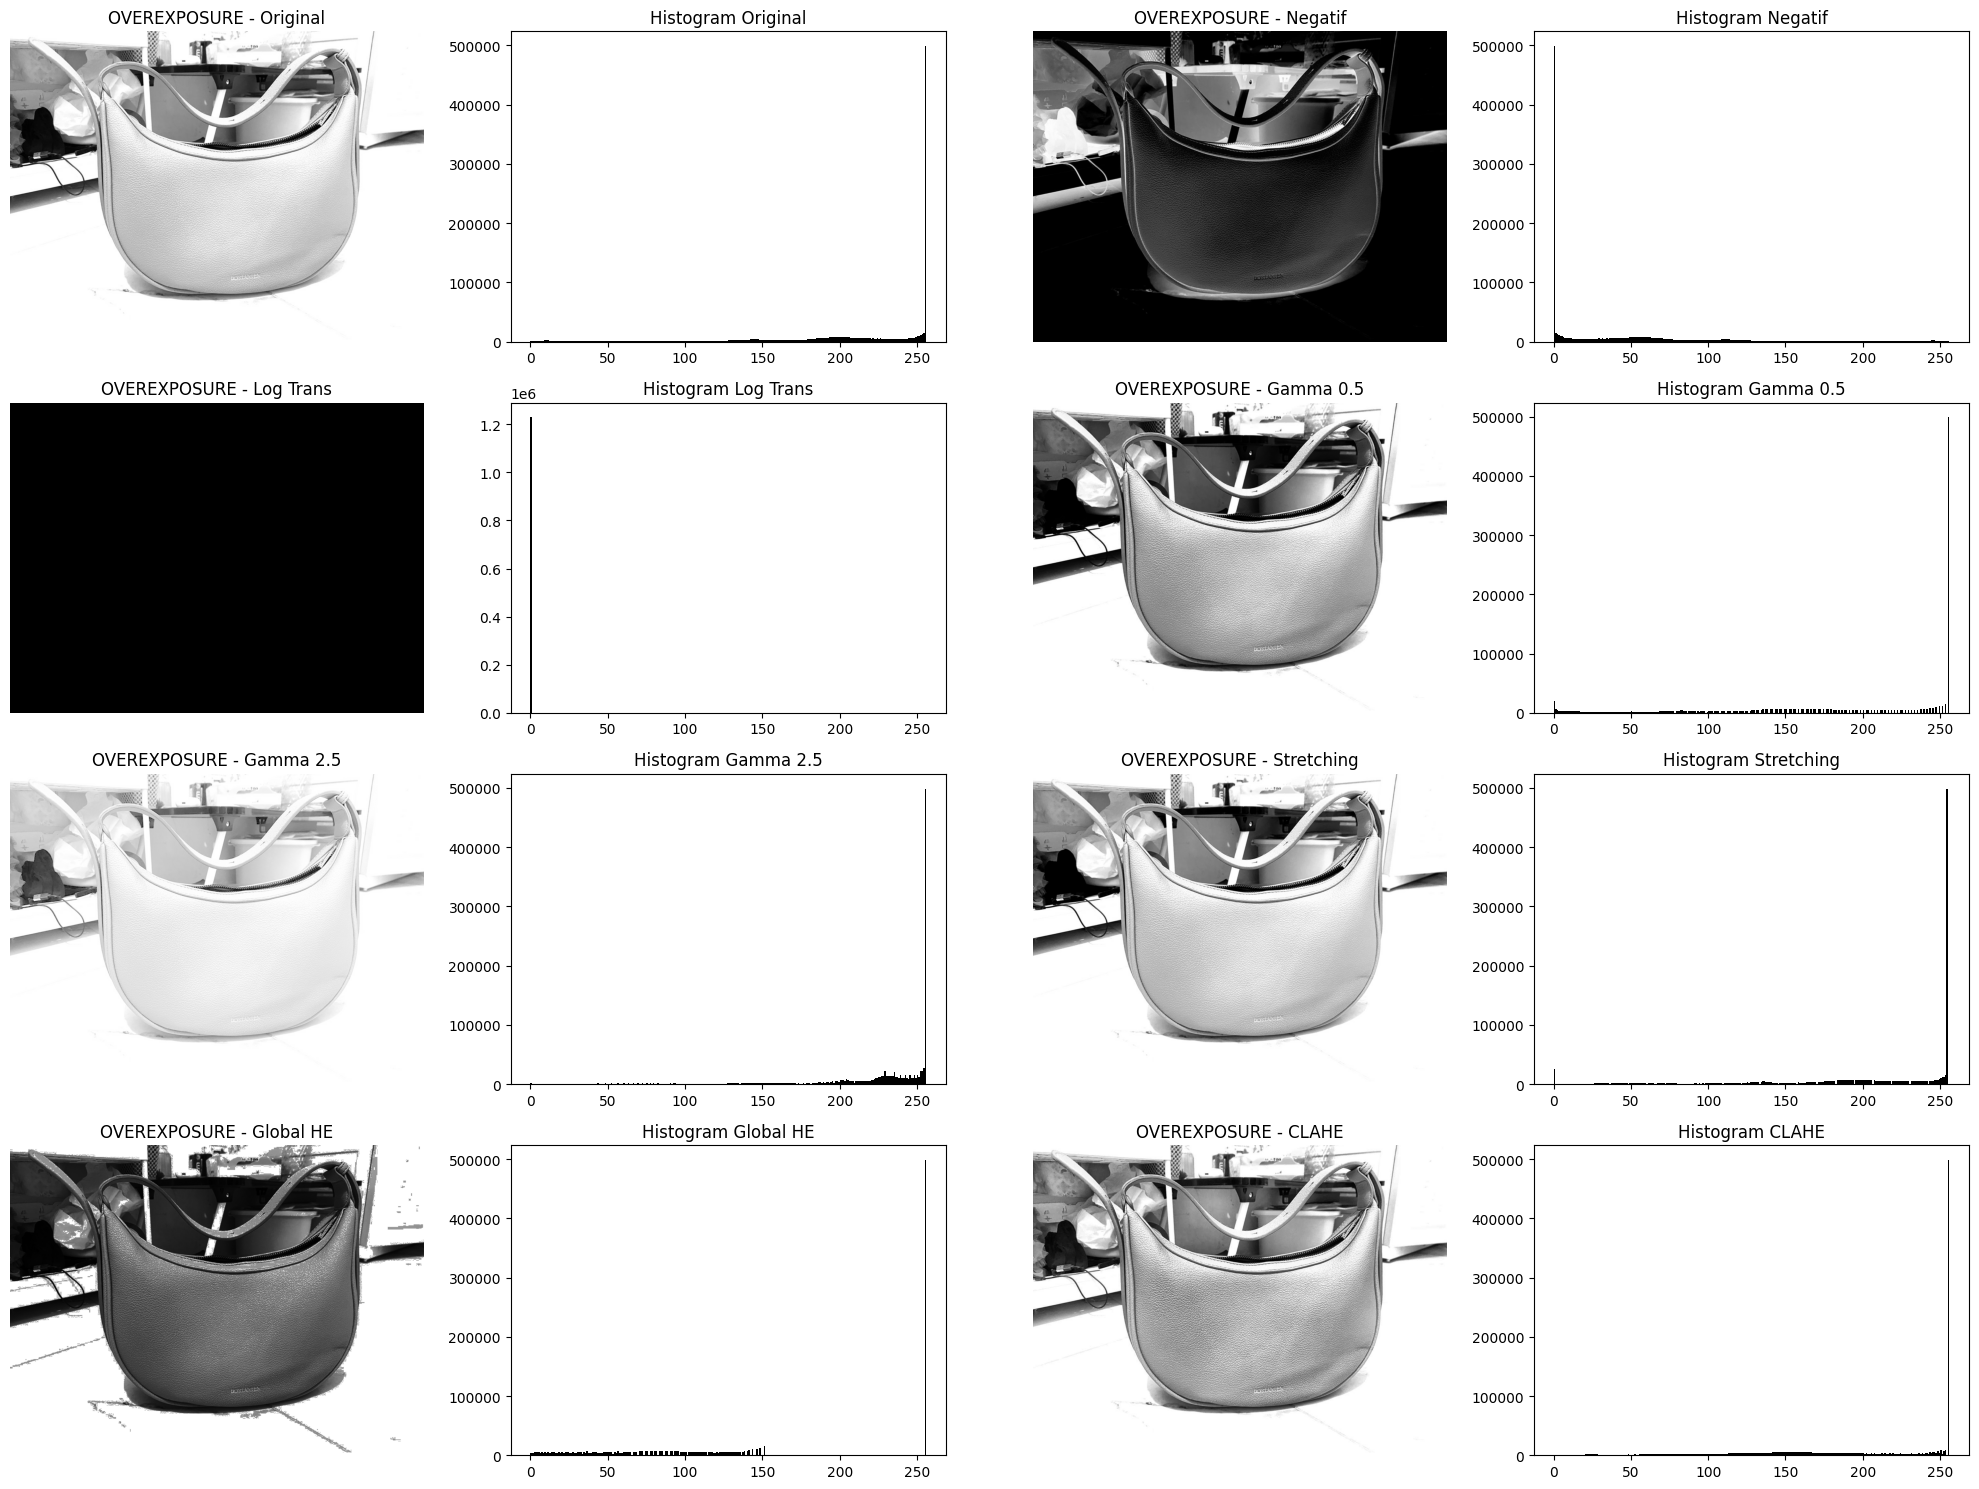


--- Analisis Metrik: UNEVEN_ILLUMINATION ---
Technique: Original     | Entropy: 7.3151 | Contrast: 58.1607
Technique: Negatif      | Entropy: 7.3151 | Contrast: 58.1607
Technique: Log Trans    | Entropy: 0.0000 | Contrast: 0.0000
Technique: Gamma 0.5    | Entropy: 7.0582 | Contrast: 65.1982
Technique: Gamma 2.5    | Entropy: 6.4397 | Contrast: 38.9321
Technique: Stretching   | Entropy: 7.1621 | Contrast: 71.5694
Technique: Global HE    | Entropy: 7.0802 | Contrast: 74.5297
Technique: CLAHE        | Entropy: 7.5955 | Contrast: 62.4377


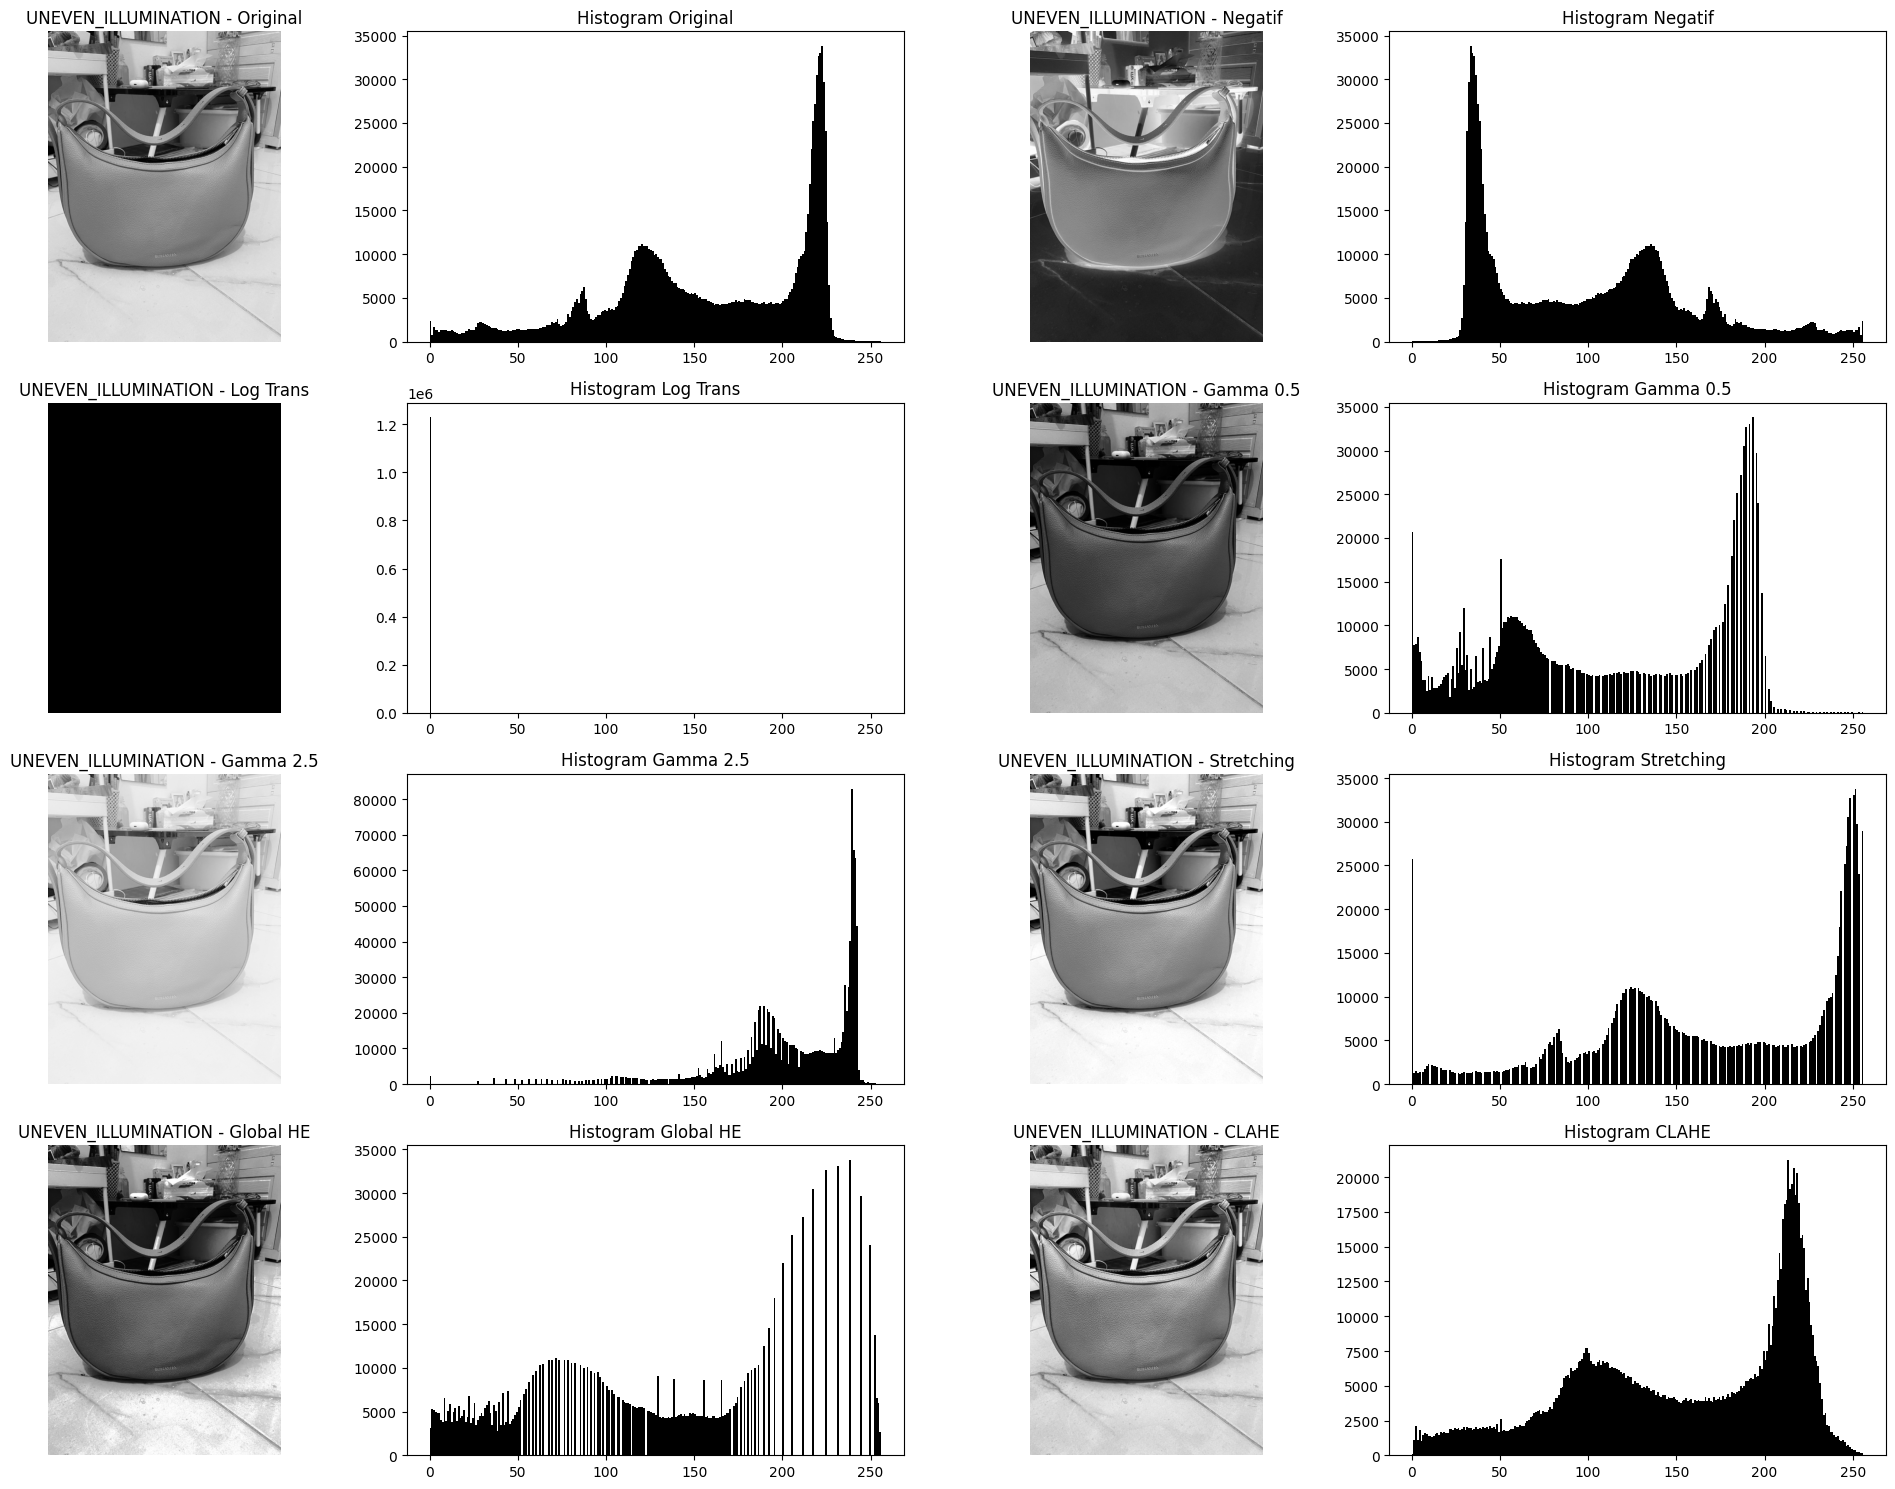

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import shannon_entropy

# --- FUNGSI UTAMA PEMROSESAN ---

def process_image(img_path, title_prefix):
    # 1. Load Citra (Grayscale)
    img = cv2.imread(img_path, 0)
    if img is None:
        print(f"Gagal memuat gambar: {img_path}")
        return

    # --- BAGIAN 2: TRANSFORMASI TITIK ---
    
    # a. Negatif
    img_negatif = 255 - img
    
    # b. Log Transformation
    c = 255 / np.log(1 + np.max(img))
    img_log = c * (np.log(1 + img.astype(np.float64)))
    img_log = np.array(img_log, dtype=np.uint8)
    
    # c. Gamma Correction (Power Law)
    def apply_gamma(image, gamma):
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        return cv2.LUT(image, table)
    
    img_gamma_low = apply_gamma(img, 0.5)  # Untuk Overexpose
    img_gamma_mid = apply_gamma(img, 1.5)
    img_gamma_high = apply_gamma(img, 2.5) # Untuk Underexpose

    # --- BAGIAN 3: PENINGKATAN BERBASIS HISTOGRAM ---
    
    # a. Contrast Stretching (Manual)
    p2, p98 = np.percentile(img, (2, 98))
    img_stretch = np.clip((img - p2) * (255.0 / (p98 - p2)), 0, 255).astype(np.uint8)
    
    # b. Histogram Equalization (Global)
    img_he = cv2.equalizeHist(img)
    
    # c. CLAHE (Local/Adaptive)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)

    # --- BAGIAN 4 & 5: EVALUASI & VISUALISASI ---
    
    results = [
        ("Original", img), ("Negatif", img_negatif), ("Log Trans", img_log),
        ("Gamma 0.5", img_gamma_low), ("Gamma 2.5", img_gamma_high),
        ("Stretching", img_stretch), ("Global HE", img_he), ("CLAHE", img_clahe)
    ]

    print(f"\n--- Analisis Metrik: {title_prefix} ---")
    fig, axes = plt.subplots(4, 4, figsize=(20, 15))
    axes = axes.ravel()

    for i, (title, processed) in enumerate(results):
        # Hitung Metrik
        ent = shannon_entropy(processed)
        std_cont = np.std(processed) # Kontras RMS (Root Mean Square)
        
        print(f"Technique: {title:12} | Entropy: {ent:.4f} | Contrast: {std_cont:.4f}")

        # Tampilkan Citra
        axes[i*2].imshow(processed, cmap='gray')
        axes[i*2].set_title(f"{title_prefix} - {title}")
        axes[i*2].axis('off')

        # Tampilkan Histogram
        axes[i*2+1].hist(processed.ravel(), 256, [0,256], color='black')
        axes[i*2+1].set_title(f"Histogram {title}")

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI TUGAS ---

# Ganti nama file di bawah ini sesuai dengan file Anda
process_image('underexpose.jpeg', 'UNDEXPOSURE')
process_image('overexpose.jpeg', 'OVEREXPOSURE')
process_image('uneven.jpeg', 'UNEVEN_ILLUMINATION')